In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import scipy.io as sio
from dataclasses import dataclass
from typing import List, Tuple
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from natsort import natsorted
import numpy as np
import matplotlib.animation as animation
import xarray as xr
import h5py
import imageio
import matplotlib
import gc
import sys
import io
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from scipy.optimize import curve_fit
import scipy.integrate
import re
import scipy.ndimage

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM
plt.rcParams.update({'font.size': 22})  

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial')


In [2]:
folder_path = r"../../../data/20260629 LSU Generated Comparison"

N_4000_n_2.9000_ff_0.2233_res_600_size_1_n_2.90.txt
Configured successfully.


Output()

13:49:07 W. Europe Daylight Time loading simulation from                        
                                 ../../../output/data/20260629 LSU Generated    
                                 Comparison\reference.txt/Data.hdf5

13:49:08 W. Europe Daylight Time WARNING: Simulation final field decay value of 
                                 1.79e-14 is greater than the simulation shutoff
                                 threshold of 1e-20. Consider running the       
                                 simulation again with a larger 'run_time'      
                                 duration for more accurate results.            

                                 Billed flex credit cost: 0.238.

...

Output()

13:49:24 W. Europe Daylight Time loading simulation from                        
                                 ../../../output/data/20260629 LSU Generated    
                                 Comparison\N_4000_n_2.9000_ff_0.2233_res_600_si
                                 ze_1_n_2.90.txt/Data.hdf5

13:49:32 W. Europe Daylight Time WARNING: Simulation final field decay value of 
                                 6.04e-06 is greater than the simulation shutoff
                                 threshold of 1e-20. Consider running the       
                                 simulation again with a larger 'run_time'      
                                 duration for more accurate results.            

13:49:33 W. Europe Daylight Time Billed flex credit cost: 6.034.

                                 Note: the task cost pro-rated due to early     
                                 shutoff was below the minimum threshold, due to
                                 fast shutoff. Decreasing the simulation        
                                 'run_time' should decrease the estimated, and  
                                 correspondingly the billed cost of such tasks.

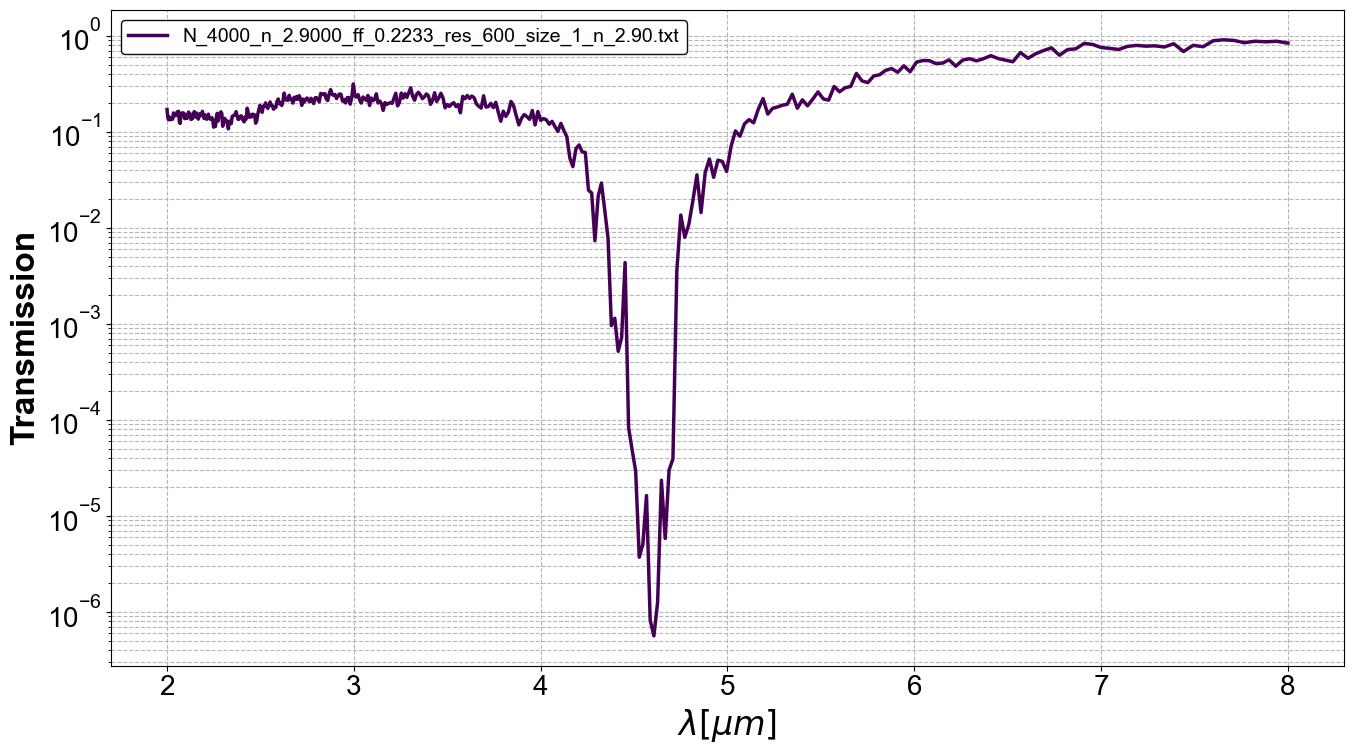

In [3]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
reference_entry=None
colors = plt.cm.viridis(np.linspace(0, 1, 3))
# Loop through all files in the folder
for dirpath, dirnames, filenames in os.walk(folder_path):
  for k,filename in enumerate(filenames):
    if filename=="reference.txt":
       continue
    if reference_entry is None:
        print(filename)
        reference_object = AM.loadFromFile(key = tidy3dAPI, file_path=os.path.join(folder_path, "reference.txt"),get_ref=False)
        reference_entry = reference_object.sim_data['flux2'].flux
        reference_exit = reference_object.sim_data['flux1'].flux
    try:
        
        #Retrieve simulation data 
        if os.path.isfile(os.path.join(dirpath, filename)):
          file=os.path.join(dirpath, filename)
          structure_1 = AM.loadFromFile(key = tidy3dAPI, file_path=file,get_ref=False)
          sim_data_i = structure_1.sim_data
          transmission_entry = (sim_data_i['flux2'].flux).values/reference_entry.values
          transmission_exit = (sim_data_i['flux1'].flux).values/reference_exit.values
          wavelength =  td.C_0/np.array(sim_data_i.simulation.monitors[0].freqs)
          ax.plot(wavelength, transmission_exit, label=filename, color=colors[k], 
               linewidth=2.5)
          
    except Exception as e:
        print("Error:", e)
        continue
    
# Styling for conference
ax.set_yscale("log")
ax.set_xlabel(rf"$\lambda[\mu m]$", fontsize=24, fontweight='bold')
ax.set_ylabel("Transmission", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=14, framealpha=0.95, edgecolor='black')
# Improve tick label size
ax.tick_params(axis='both', which='major', labelsize=20)
# Add subtle background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()
       


